<a href="https://colab.research.google.com/github/VirginiaVega/PROJECT_ROOT/blob/main/TPFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Descripcion del DataSet y las variables:

Los datos son sobre campañas de marketing mediante llamadas telefonicas de una entidad bancaria portuguesa. El objetivo es predecir si el cliente se suscribira un deposito a plazo o no(variable Y).
 A menudo, era necesario contactar con el mismo cliente varias veces para determinar si el producto (depósito a plazo fijo) estaría suscrito (sí) o no (no).

Variables:
#### DATOS DEL CLIENTE BANCARIO:
- Age (edad): numerica int64  
- Job (tipo de empleo): categorico object: empleado doméstico (housemaid), servicios (services), administrador (admin.), obrero (blue-collar), técnico (technician), jubilado (retired), gerencia (management), desempleado (unemployed), autónomo (self-employed), desconocido (unknown), empresario (entrepreneur), estudiante (student).
- Marital (estado civil): categorico object: married, single, divorced, unknown.
- Education (nivel de educacion): categorico object: basica.4a, basica.6a, basica 9.a, secundaria, analfabeto (illiterate), curso profesional, titulo universitario, desconocido.
- Default (¿tiene credito en mora?): categorico object: no, si, desconocido.
- Housing (¿Tiene prestamo hipotecario?): categorico object: no, si, desconocido.
- Loan (¿Tiene prestamo personal?): categorico object: no, si, desconocido.

#### RELACIONADO CON EL ULTIMO CONTACTO DE LA CAMPAÑA ACTUAL:
- Contact (Tipo de comunicacion de contacto): categorico object: celular, telefono.
- Month (Ultimo mes de contacto): categorico object: ene, feb, mar .... nov, dic.
- Day_of_week (ultimo dia de contacto): categorico object: monday, tuesday, wednesday, thursday, friday.
- Duration (duracion del ultimo contacto en segundos): numerico int64.

Nota importante: Este atributo afecta considerablemente el resultado objetivo (p. ej., si
duración = 0, entonces y = 'no'). Sin embargo, la duración no se conoce antes de
realizar una llamada. Además, después de finalizar la llamada, y se conoce obviamente.
Por lo tanto, esta entrada solo debe incluirse para fines de referencia y
debe descartarse si se pretende obtener un
modelo predictivo realista.

#### OTROS ATRIBUTOS:
- Campaign (numero de contactos realizados durante esta campaña y para este cliente): numerico int64.
- Pdays (Dias transcurridos desde el ultimo contacto con el cliente de una campaña anterior): numerico int64. Si el valor es 999 significa que el cliente no fue contactado previamente.
- Previous (numero de contactos realizados antes de esta campaña y para este cliente): numerico int64.
- Poutcome (Resultado de la ultima campaña de marketing): categorico object: inexistente, fracaso, exito.

#### ATRIBUTOS DEL CONTEXTO SOCIAL Y ECONOMICO:
- Emp.var.rate (Tasa de variacion del empleo) Indicador trimestral. Numerico float64.
- Cons.price.idx (Indice de precio al consumidor) Indicador mensual. Numerico float64.
- Cons.conf.idx (Indice de confianza del consumidor) Indicador mensual. Numerico float64.
- Euribor3m (Tipo de interes del euribor a 3 meses) Indicador diario. Numerico float64.
- Nr.employed (Numero de empleados) Indicador trimestral.  Numerico float64.

#### VARIABLE DE SALIDA - OBJETIVO
- y ¿el cliente ha suscrito un depósito a plazo? (binario: 'sí', 'no')

In [ ]:
#Ejecute instalacion de versiones:
# sklearn: 1.4.2
# xgboost: 3.0.4
# numpy: 1.26.4
# pandas: 2.1.4
!pip install scikit-learn==1.4.2 xgboost==3.0.4 numpy==1.26.4 pandas==2.1.4

In [ ]:
#Reinicar el Kernel
import os
import sys
os.kill(os.getpid(), 9)

In [28]:
#Corroborar las versiones
import sklearn, xgboost, numpy, pandas
print(sklearn.__version__, xgboost.__version__, numpy.__version__, pandas.__version__)

1.4.2 3.0.4 1.26.4 2.1.4


In [29]:
# Librerias y configuración
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor



df=pd.read_csv("bank-additional-full.csv", encoding='utf-8', sep=';')

## CARGA Y EXPLORACIÓN INICIAL DE DATOS

In [31]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

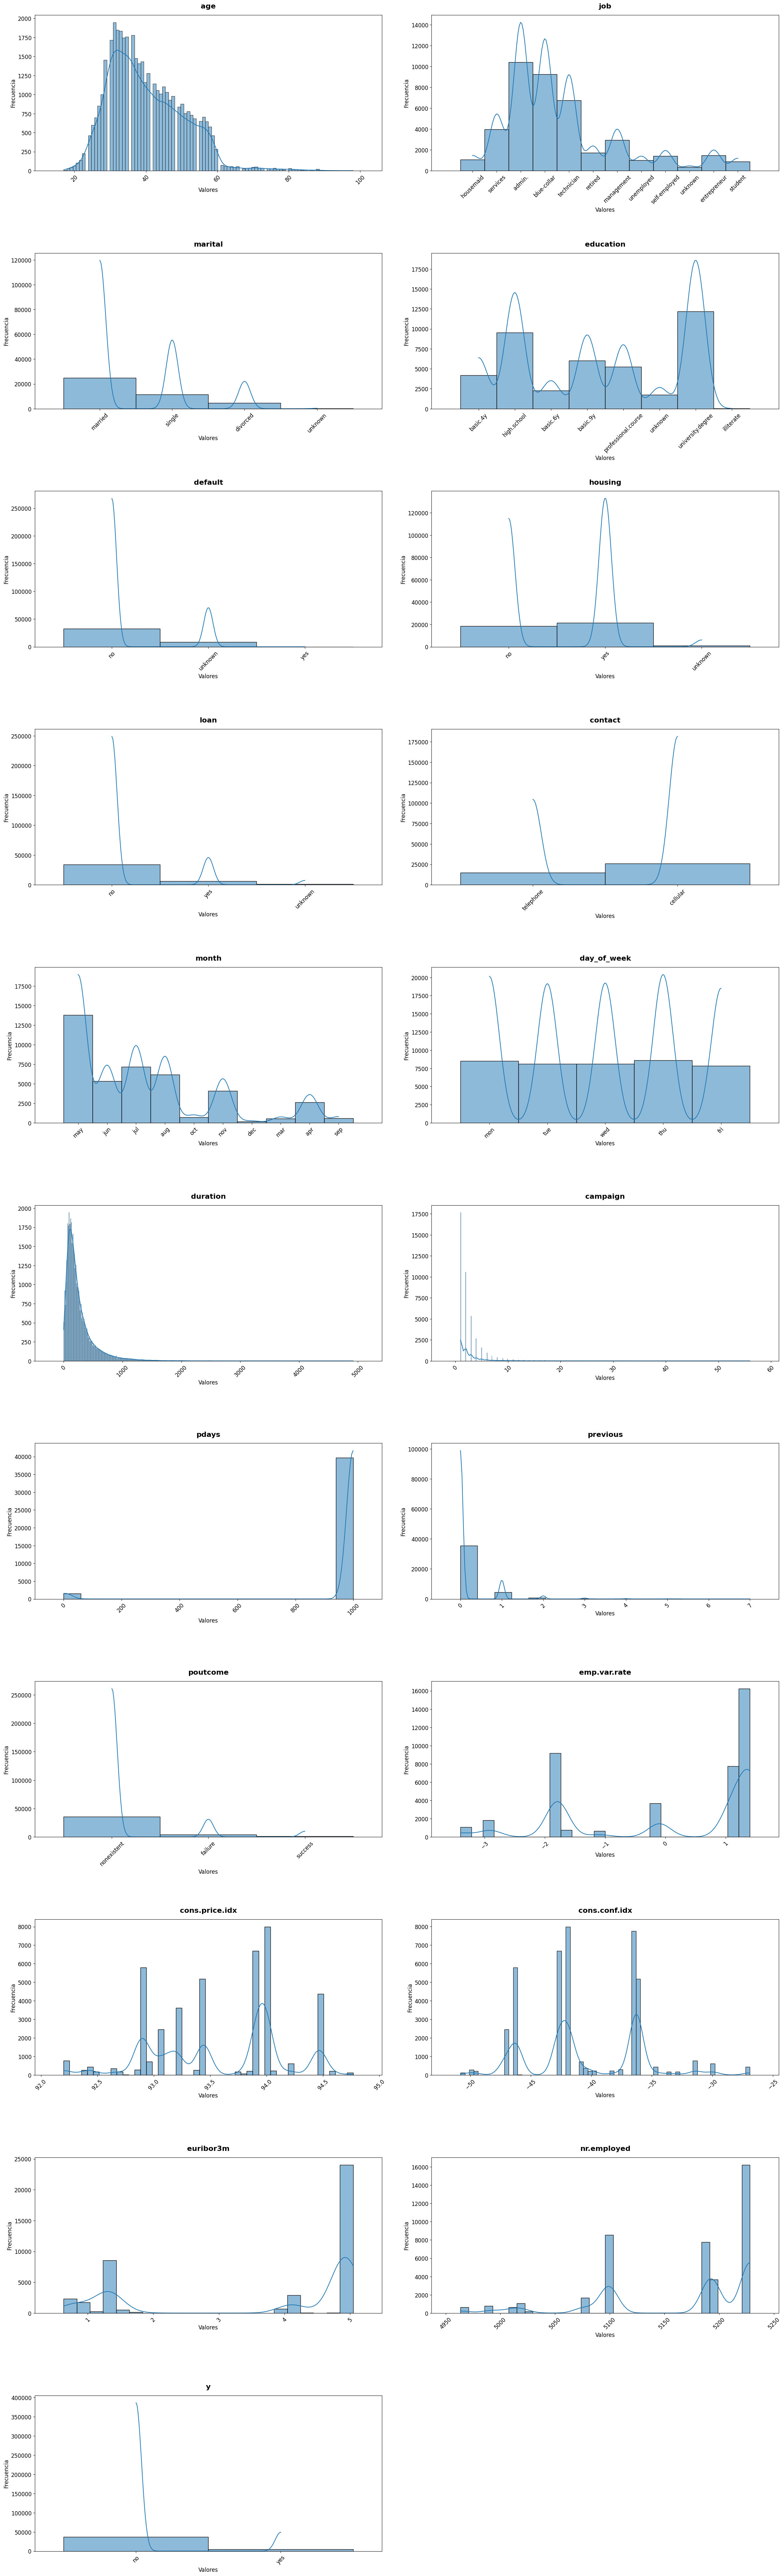

In [8]:
#VER DISTRIBUCIONES
fig, axes = plt.subplots(11, 2, figsize=(25, 80))
axes = axes.ravel()

for i, columna in enumerate(df.columns):
    sns.histplot(df[columna].dropna(), ax=axes[i], kde=True)
    axes[i].set_title(columna, fontsize=16, fontweight='bold', pad=15)
    axes[i].tick_params(axis='x', rotation=45, labelsize=12)
    axes[i].tick_params(axis='y', labelsize=12)
    axes[i].set_xlabel('Valores', fontsize=12)
    axes[i].set_ylabel('Frecuencia', fontsize=12)
    axes[i].margins(x=0.1)

if len(df.columns) < len(axes):
    axes[-1].set_visible(False)

plt.tight_layout(pad=4.0)
plt.show()

Counts: y
no     36548
yes     4640
Name: count, dtype: int64
ratio de (yes): 0.11


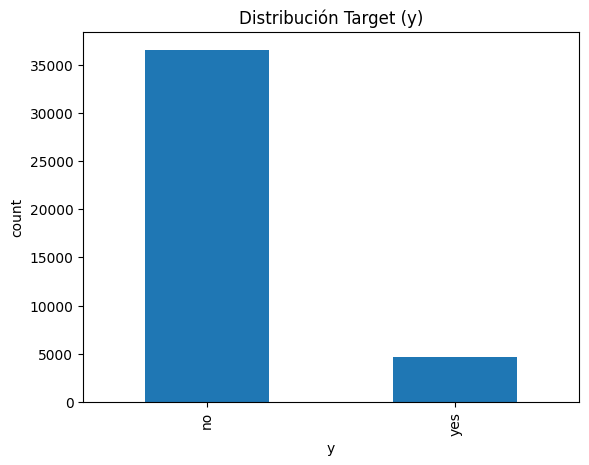

In [33]:
#DEFINICION DEL TARGET
target = df['y'].value_counts()
print("Counts:", target)
rate = target.get('yes', 0) / target.sum()
print(f"ratio de (yes): {rate:.2f}")

#Grafico
target.plot(kind='bar')
plt.title('Distribución Target (y)')
plt.xlabel('y')
plt.ylabel('count')
plt.show()
#Alto desbalance en datos

# PREPARACION DE LOS DATOS

job: 330
marital: 80
education: 1731
default: 8597
housing: 990
loan: 990
contact: 0
month: 0
day_of_week: 0
poutcome: 0
y: 0


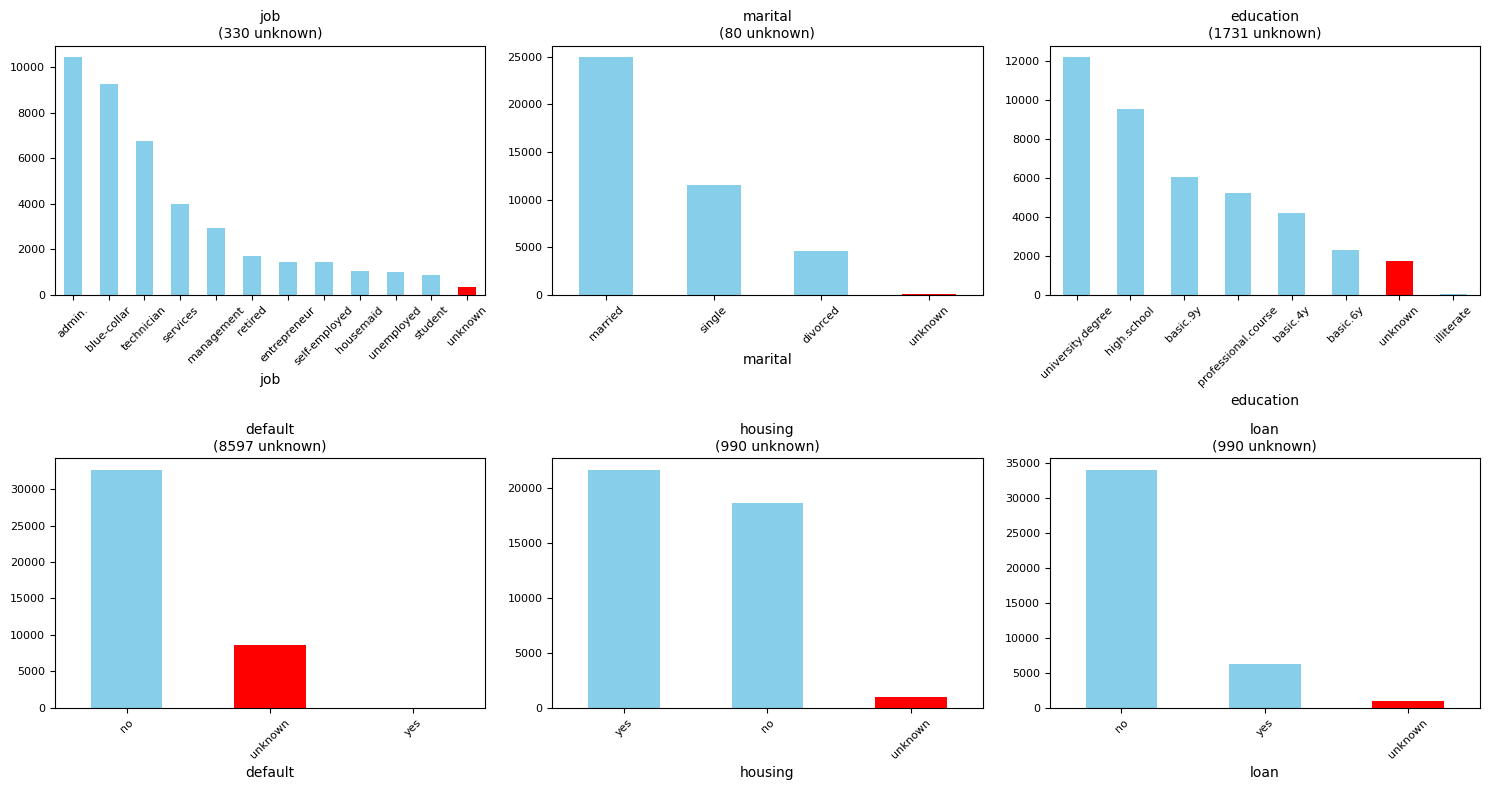

In [34]:
#Copia del modelo:
df_model = df.copy()


#REVISION DE VARIABLES OBJECT CON VALORES 'UNKNOW'
variables_con_unknown = []
conteos_unknown = []

for col in df_model.select_dtypes(include='object').columns:
    unknown_count = (df_model[col] == 'unknown').sum()
    print(f'{col}: {unknown_count}')
    variables_con_unknown.append(col)
    conteos_unknown.append(unknown_count)

# GRAFICAR:
vars_a_graficar = [(col, count) for col, count in zip(variables_con_unknown, conteos_unknown) if count > 0]
n_vars = len(vars_a_graficar)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
for i, (col, unknown_count) in enumerate(vars_a_graficar):
    if i < len(axes):
        value_counts = df_model[col].value_counts()
        colors = ['red' if idx == 'unknown' else 'skyblue' for idx in value_counts.index]
        value_counts.plot(kind='bar', ax=axes[i], color=colors)
        axes[i].set_title(f'{col}\n({unknown_count} unknown)', fontsize=10)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', labelsize=8)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [35]:
#ELIMINAR VARIABLES:

#Var duration por data leakage
if 'duration' in df_model.columns:
    df_model = df_model.drop(columns=['duration'])

# Var 'default' por exceso de valores 'unknown' y bajo aporte real
if 'default' in df_model.columns:
    df_model = df_model.drop(columns=['default'])

#### Eliminacion de variables
- Duration: Esta variable representa la duracion de la llamada con el cliente. Es un caso de *data leakage*: solo se conoce después de realizar la campaña, por lo que no puede usarse para predecir de antemano.
- Default: Esta variable indica si el cliente tiene créditos en mora, lo que sería información valiosa. Sin embargo, en este dataset concreto más del **20% de los registros son "unknown"**, y además casi no hay casos en "yes". Su valor predictivo real es muy bajo y puede introducir ruido. Decidimos **descartarla** para mantener un dataset más limpio.

In [36]:
#DEFINICION DE VARIABLES PREDICTORAS Y EL TARGET

X = df_model.drop(columns=['y'])
y = df_model['y'].apply(lambda x: 1 if x == 'yes' else 0)

print("Variables finales en X:", X.columns.tolist())
print("Shape X:", X.shape, "Shape y:", y.shape)

Variables finales en X: ['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Shape X: (41188, 18) Shape y: (41188,)


## ANALIZAR CORRELACIONES, ASOCIACIONES Y COLINEALIDAD ENTRE LAS VARIABLES

In [37]:
#CORRELACIONES, ASOCIACIONES Y COLINEALIDAD:

# Entre variables numericas y el target (Point-Biserial) Cuales son las mas relevantes para predecir el target

# Entre variables numericas (VIF: Variance Inflation Factor) Cuales son mas rebundantes entre si. (para modelos lineales)

# Entre variables numericas (Pearson): grafico Numérica vs Numérica

# Entre variables categoricas y el target (Cramer's V junto con Chi-cuadrado) - Mide si existe relacion y que tan fuerte es entre cada Var categ y el Target

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categóricas: ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


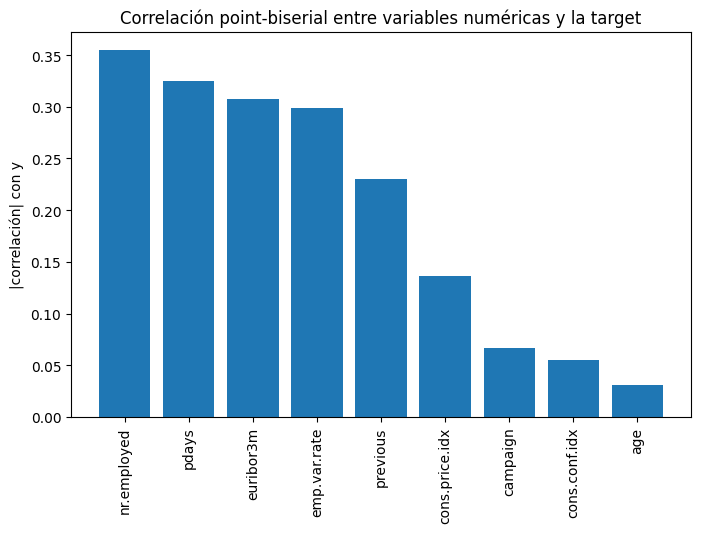

In [38]:
# Entre variables numericas y el target (Point-Biserial) ya que el target es binario. Medimos las mas relevantes para predecir el Target
from scipy.stats import pointbiserialr
rows = []
for col in num_cols:
    r, p = pointbiserialr(y, X[col])
    rows.append({"variable": col, "corr_pointbiserial": r, "p_value": p})

pb_df = pd.DataFrame(rows).sort_values(by="corr_pointbiserial", key=np.abs, ascending=False)
pb_df
# Grafico
plt.figure(figsize=(8,5))
plt.bar(pb_df["variable"], pb_df["corr_pointbiserial"].abs())
plt.xticks(rotation=90)
plt.ylabel("|correlación| con y")
plt.title("Correlación point-biserial entre variables numéricas y la target")
plt.show()

In [39]:
#Entre variables numericas (VIF: Variance Inflation Factor) para multicolinealidad entre las numericas. (para modelos lineales)
#Si presentan rebundancia considerar cuales eliminar teniendo en cuenta la importancia que tiene cada variable para predecir el target (Point-Biserial)

X_vif = X[num_cols].copy().dropna()
X_vif_const = sm.add_constant(X_vif)

vif = pd.DataFrame({
    "variable": ["const"] + X_vif.columns.tolist(),
    "VIF": [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]
})
vif = vif[vif["variable"]!="const"].sort_values("VIF", ascending=False)
vif

,variable,VIF
8,euribor3m,64.342881
5,emp.var.rate,33.070180
9,nr.employed,31.662087
6,cons.price.idx,6.337933
7,cons.conf.idx,2.648960
4,previous,1.795642
3,pdays,1.612602
2,campaign,1.033689
1,age,1.018878


Interpretacion de VIF:
* VIF = 1: No hay multicolinealidad
* VIF < 5: Multicolinealidad aceptable
* VIF 5-10: Multicolinealidad moderada
* VIF > 10: Multicolinealidad alta  (problema serio)

# Definir que variables que presentan multicolinealidad tenemos que eliminar

nr.employed por ej, tiene Point-B alto lo que indica que es muy relevante para predecir el target, y el valor VIF tambien es alto, lo que indica que tiene variables que son rebundantes con esta.

euribor3m por ej, tiene Point-B alto, no tanto como nr.employed, y el valor de VIF es mucho mas alto, indicando que es la variable con mayor rebundancia

emp.var.rate por ej, tiene Point-B casi a la misma altura que euribor3m, y el valor de VIF esta entre nr.employed y euribor3m.

La decision que tomamos es eliminar las variables euribor3m y emp.var.rate ya que no son tan relevante para predecir el target y tiene los valores de VIF mas altos. Esto eliminaria la multicolinealidad.

In [40]:
#ELIMINACION DE VARIABLES MUY CORRELACIONADAS:

# Var 'euribor3m' por alta rebundancia
if 'euribor3m' in df_model.columns:
    df_model = df_model.drop(columns=['euribor3m'])

# Var 'emp.var.rate' por alta rebundancia
if 'emp.var.rate' in df_model.columns:
    df_model = df_model.drop(columns=['emp.var.rate'])

In [17]:
#REDEFINICION DE VARIABLES PREDICTORAS Y EL TARGET

X = df_model.drop(columns=['y'])
y = df_model['y'].apply(lambda x: 1 if x == 'yes' else 0)

In [41]:
#VARIABLES NUMERICAS QUE QUEDARON:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

print("Numéricas:", num_cols)

Numéricas: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


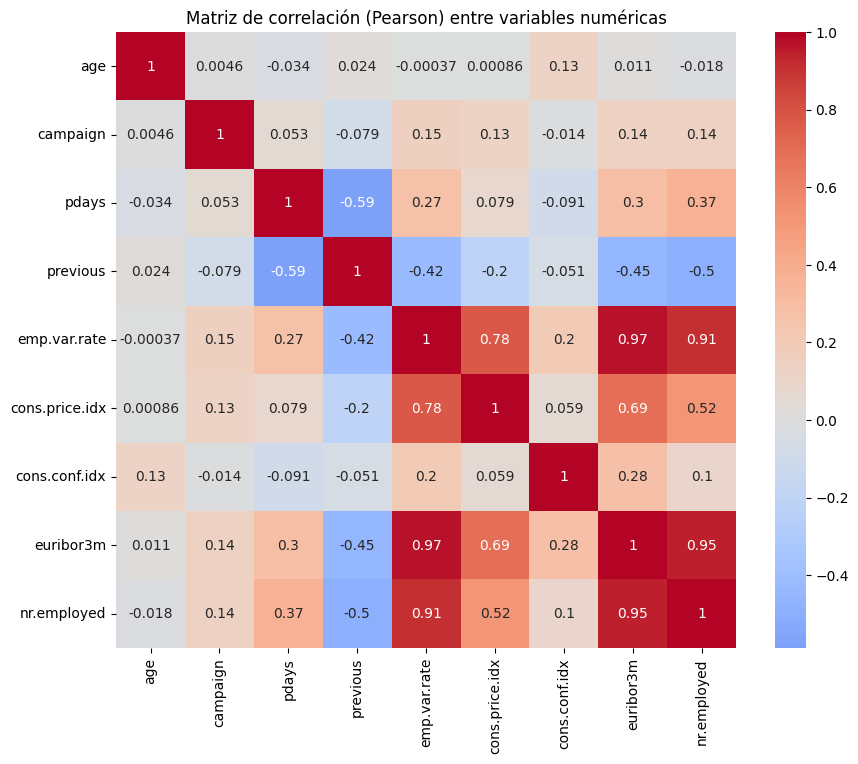

In [42]:
#Entre variables numericas (Pearson) Para ver si hay variables que se parecen demasiado.

#Ej: Emp.var.rate con euriborn3m y nr.employed
corr_num = X[num_cols].corr(method='pearson')
plt.figure(figsize=(10,8))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', center=0)
plt.title("Matriz de correlación (Pearson) entre variables numéricas")
plt.show()

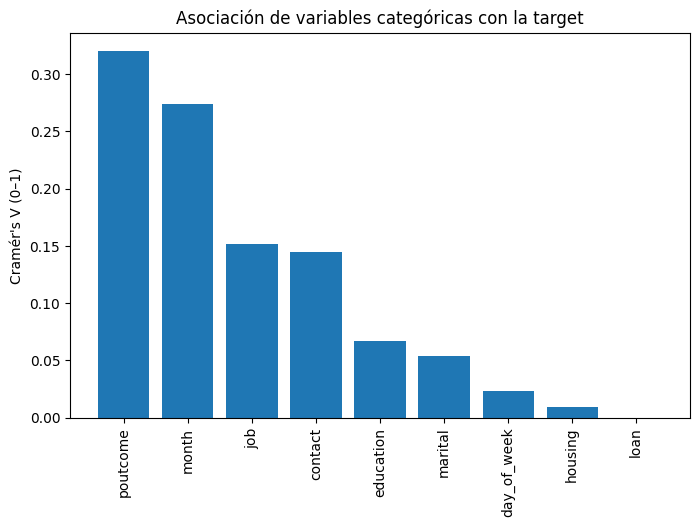

In [43]:
# Entre variables categoricas y el target (Cramer's V junto con Chi-cuadrado)

def cramers_v(x, y_bin):
    tab = pd.crosstab(x, y_bin)
    chi2 = chi2_contingency(tab)[0]
    n = tab.values.sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

rows = []
for col in cat_cols:
    rows.append({"variable": col, "cramers_v": cramers_v(X[col], y)})

cramers_df = pd.DataFrame(rows).sort_values("cramers_v", ascending=False)
cramers_df

# Grafico
plt.figure(figsize=(8,5))
plt.bar(cramers_df["variable"], cramers_df["cramers_v"])
plt.xticks(rotation=90)
plt.ylabel("Cramér's V (0–1)")
plt.title("Asociación de variables categóricas con la target")
plt.show()

# INGENIERIA DE VARIABLES


In [44]:
# VAR 'PDAYS' TRATAMIENTO:
print("Valores únicos de pdays:")
print(X['pdays'].value_counts().sort_index())
#Crear la variable 'prev_contact' para saber si fue contactado previamente.
#Crear otra variable 'pdays_eff' para los que SI fueron contactados (aplicando -1 a quienes no lo fueron)

X['prev_contact'] = (X['pdays'] != 999).astype(int)  # Binaria: 1=contactado, 0=nunca
X['pdays_eff'] = np.where(X['pdays'] != 999, X['pdays'], -1)  # -1 para nunca contactado

X = X.drop('pdays', axis=1) # Eliminar la variable original

Valores únicos de pdays:
pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64


In [45]:
print("Variables finales en X:", X.columns.tolist())
print("Shape X:", X.shape, "Shape y:", y.shape)

Variables finales en X: ['age', 'job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'prev_contact', 'pdays_eff']
Shape X: (41188, 19) Shape y: (41188,)


## PREPROCESAMIENTO DE DATOS

Intento de usar GridSearch para ajustar los hiperparametros de los modelos pero no solo que no mejoraban la performance de los mismos sino que requieren mucho recurso computacional, por lo tanto, los modelos tardan demasiado en entrenar.

In [46]:
# Separacion de los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Separacion variables numericas de categoricas
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

# Escalar numeros y transformar categorias:
numeric_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Aca aplica las transformaciones cuando se llama al preprocesador
preprocessor = ColumnTransformer([
    ("num", numeric_tf, num_cols),
    ("cat", categorical_tf, cat_cols)
], remainder="drop", sparse_threshold=0.0)

# MODELADO Y EVALUACIÓN

In [47]:
# Definir modelos a comparar
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),

    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        bootstrap=True,
        max_depth=10,
        class_weight='balanced'
    ),

    'XGBoost': XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # Balance de clases
    max_depth=4,           # Reducir overfitting
    learning_rate=0.1,     # Tasa de aprendizaje óptima
    n_estimators=200,      # Más árboles
    subsample=0.8,         # Regularización
    colsample_bytree=0.8
    )

}

# Almacenar resultados
results = {}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    print(f"\n Entrenando {name}...")


        # Crear pipeline completo
    pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor), #Aplicar transformaciones
            ('classifier', model) #Modelar con datos transformados
        ])

        # Entrenar modelo
    pipeline.fit(X_train, y_train)

    # Predecir
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)

    # Almacenar resultados
    results[name] = {
        'model': pipeline,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    print(f" Accuracy: {accuracy:.4f}, \n Precision: {precision:.4f},\n Recall: {recall:.4f},\n F1: {f1:.4f}, \n AUC-ROC: {auc_roc:.4f}")


 Entrenando Logistic Regression...
 Accuracy: 0.8342, 
 Precision: 0.3658,
 Recall: 0.6433,
 F1: 0.4664, 
 AUC-ROC: 0.8007

 Entrenando Random Forest...
 Accuracy: 0.8642, 
 Precision: 0.4298,
 Recall: 0.6304,
 F1: 0.5111, 
 AUC-ROC: 0.8120

 Entrenando XGBoost...
 Accuracy: 0.8454, 
 Precision: 0.3887,
 Recall: 0.6509,
 F1: 0.4867, 
 AUC-ROC: 0.8099


# COMPARATIVA DE MODELOS

In [48]:
print("\n" + "=" * 40)
print("COMPARATIVA DE MODELOS")
print("=" * 40)

# Crear DataFrame de resultados
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[name]['accuracy'] for name in results],
    'Precision': [results[name]['precision'] for name in results],
    'Recall': [results[name]['recall'] for name in results],
    'F1-Score': [results[name]['f1'] for name in results],
    'AUC-ROC': [results[name]['auc_roc'] for name in results]
})

print("\n RESUMEN DE MÉTRICAS POR MODELO:")
print(results_df.round(4))

# Identificar mejor modelo basado en recall (objetivo principal)
best_model_name = results_df.loc[results_df['Recall'].idxmax(), 'Model']
print(f"\n MEJOR MODELO: {best_model_name} (Recall más alto)")



COMPARATIVA DE MODELOS

 RESUMEN DE MÉTRICAS POR MODELO:
                 Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0  Logistic Regression    0.8342     0.3658  0.6433    0.4664   0.8007
1        Random Forest    0.8642     0.4298  0.6304    0.5111   0.8120
2              XGBoost    0.8454     0.3887  0.6509    0.4867   0.8099

 MEJOR MODELO: XGBoost (Recall más alto)


ANÁLISIS DEL MEJOR MODELO

ANÁLISIS DETALLADO DEL MEJOR MODELO: XGBoost

 MATRIZ DE CONFUSIÓN:
[[6360  950]
 [ 324  604]]


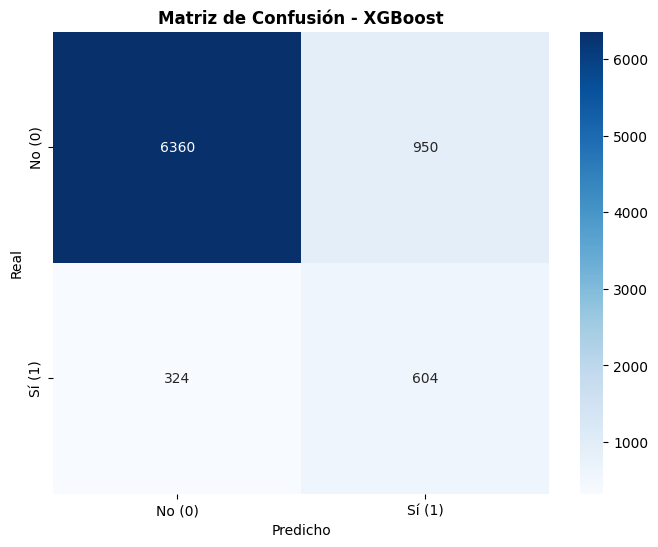


 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

 No Suscribe       0.95      0.87      0.91      7310
    Suscribe       0.39      0.65      0.49       928

    accuracy                           0.85      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.85      0.86      8238



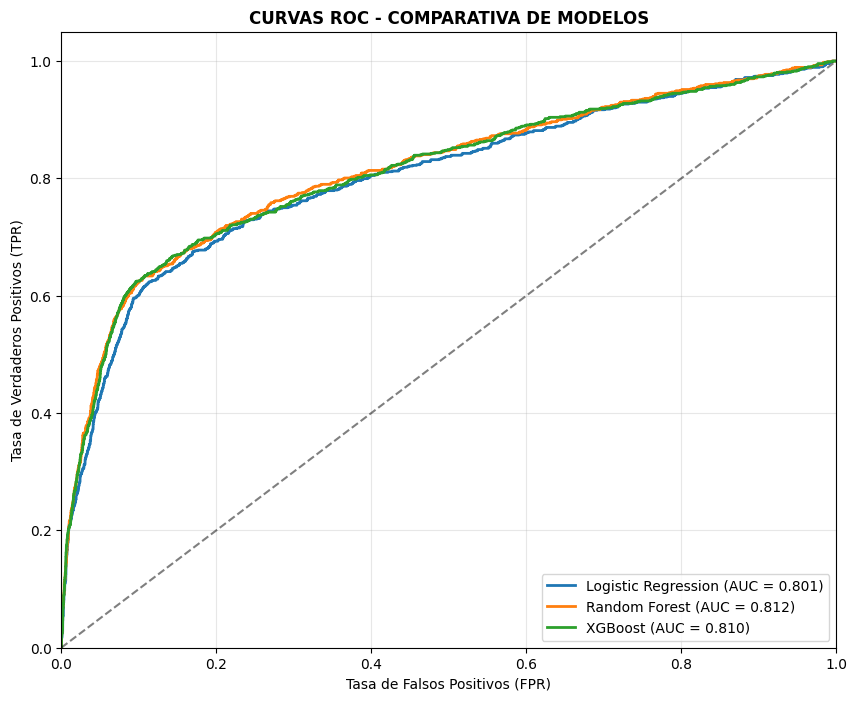

In [49]:
print(f"ANÁLISIS DETALLADO DEL MEJOR MODELO: {best_model_name}")

best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['predictions']
y_pred_proba_best = results[best_model_name]['probabilities']

# Matriz de confusión
print("\n MATRIZ DE CONFUSIÓN:")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)

# Gráfico de matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No (0)', 'Sí (1)'],
            yticklabels=['No (0)', 'Sí (1)'])
plt.title(f'Matriz de Confusión - {best_model_name}', fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Reporte de clasificación
print("\n REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred_best,
                          target_names=['No Suscribe', 'Suscribe']))

# Curva ROC
plt.figure(figsize=(10, 8))

# Calcular curva ROC para cada modelo
for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['probabilities'])
    auc_score = results[name]['auc_roc']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('CURVAS ROC - COMPARATIVA DE MODELOS', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

IMPACTO DE NEGOCIO

In [50]:
# ANÁLISIS DE IMPACTO ECONÓMICO
def business_impact_analysis(model, X_test, y_test, cost_per_call=2, revenue_per_conversion=100):
    """
    Calcula el impacto económico del modelo
    cost_per_call: costo estimado por llamada telefónica
    revenue_per_conversion: ingreso promedio por depósito suscrito
    """

    # Predicciones
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Métricas base
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_calls = len(y_test)
    actual_conversions = y_test.sum()

    # ESCENARIO SIN MODELO (contactar a todos)
    cost_no_model = total_calls * cost_per_call
    revenue_no_model = actual_conversions * revenue_per_conversion
    profit_no_model = revenue_no_model - cost_no_model

    # ESCENARIO CON MODELO (solo contactar predicciones positivas)
    calls_with_model = (y_pred == 1).sum()
    cost_with_model = calls_with_model * cost_per_call
    revenue_with_model = tp * revenue_per_conversion
    profit_with_model = revenue_with_model - cost_with_model

    # Mejora
    profit_improvement = profit_with_model - profit_no_model
    cost_reduction = cost_no_model - cost_with_model
    efficiency_gain = (tp / calls_with_model) if calls_with_model > 0 else 0

    return {
        'escenario_sin_modelo': {
            'llamadas': total_calls,
            'costo_total': cost_no_model,
            'ingresos': revenue_no_model,
            'beneficio': profit_no_model,
            'tasa_conversion': actual_conversions / total_calls
        },
        'escenario_con_modelo': {
            'llamadas': calls_with_model,
            'costo_total': cost_with_model,
            'ingresos': revenue_with_model,
            'beneficio': profit_with_model,
            'tasa_conversion': tp / calls_with_model if calls_with_model > 0 else 0
        },
        'mejoras': {
            'reduccion_costo': cost_reduction,
            'incremento_beneficio': profit_improvement,
            'incremento_eficiencia': efficiency_gain,
            'llamadas_evitadas': total_calls - calls_with_model
        }
    }

# Calcular impacto
impacto = business_impact_analysis(best_model, X_test, y_test)

print("\n" + "="*50)
print("ANÁLISIS DE IMPACTO ECONÓMICO")
print("="*50)
print(f"Escenario sin modelo:")
print(f"  • Llamadas realizadas: {impacto['escenario_sin_modelo']['llamadas']:,}")
print(f"  • Costo total: ${impacto['escenario_sin_modelo']['costo_total']:,.2f}")
print(f"  • Tasa conversión: {impacto['escenario_sin_modelo']['tasa_conversion']:.1%}")

print(f"\nEscenario con modelo:")
print(f"  • Llamadas realizadas: {impacto['escenario_con_modelo']['llamadas']:,}")
print(f"  • Costo total: ${impacto['escenario_con_modelo']['costo_total']:,.2f}")
print(f"  • Tasa conversión: {impacto['escenario_con_modelo']['tasa_conversion']:.1%}")

print(f"\nMEJORAS:")
print(f"  • Reducción de costos: ${impacto['mejoras']['reduccion_costo']:,.2f}")
print(f"  • Incremento beneficio: ${impacto['mejoras']['incremento_beneficio']:,.2f}")
print(f"  • Llamadas evitadas: {impacto['mejoras']['llamadas_evitadas']:,}")
print(f"  • Eficiencia: {impacto['mejoras']['incremento_eficiencia']:.1%}")


ANÁLISIS DE IMPACTO ECONÓMICO
Escenario sin modelo:
  • Llamadas realizadas: 8,238
  • Costo total: $16,476.00
  • Tasa conversión: 11.3%

Escenario con modelo:
  • Llamadas realizadas: 1,554
  • Costo total: $3,108.00
  • Tasa conversión: 38.9%

MEJORAS:
  • Reducción de costos: $13,368.00
  • Incremento beneficio: $-19,032.00
  • Llamadas evitadas: 6,684
  • Eficiencia: 38.9%


----





-

**Análisis de segmentación por probabilidad** - GABY REVISAR ⏰

In [ ]:
# Análisis de segments por probabilidad
def probability_segment_analysis(model, X_test, y_test):
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Definir segmentos por percentil de probabilidad
    segments = {
        'Alta_probabilidad': (0.7, 1.0),
        'Media_probabilidad': (0.3, 0.7),
        'Baja_probabilidad': (0.0, 0.3)
    }

    segment_results = {}

    for segment_name, (min_prob, max_prob) in segments.items():
        mask = (y_pred_proba >= min_prob) & (y_pred_proba < max_prob)
        if mask.sum() > 0:
            segment_y_true = y_test[mask]
            segment_y_pred_proba = y_pred_proba[mask]

            conversion_rate = segment_y_true.mean()
            segment_size = mask.sum()
            total_conversions = segment_y_true.sum()

            segment_results[segment_name] = {
                'tamaño_segmento': segment_size,
                'tasa_conversion': conversion_rate,
                'conversiones_totales': total_conversions,
                'porcentaje_poblacion': segment_size / len(y_test)
            }

    return segment_results

segment_analysis = probability_segment_analysis(best_model, X_test, y_test)

print("\nANÁLISIS DE SEGMENTACIÓN POR PROBABILIDAD:")
for segment, metrics in segment_analysis.items():
    print(f"\n{segment}:")
    print(f"  • Tamaño: {metrics['tamaño_segmento']:,} clientes ({metrics['porcentaje_poblacion']:.1%})")
    print(f"  • Tasa conversión: {metrics['tasa_conversion']:.1%}")
    print(f"  • Conversiones: {metrics['conversiones_totales']:,}")


ANÁLISIS DE SEGMENTACIÓN POR PROBABILIDAD:

Alta_probabilidad:
  • Tamaño: 1,005 clientes (12.2%)
  • Tasa conversión: 48.1%
  • Conversiones: 483

Media_probabilidad:
  • Tamaño: 4,100 clientes (49.8%)
  • Tasa conversión: 7.9%
  • Conversiones: 325

Baja_probabilidad:
  • Tamaño: 3,133 clientes (38.0%)
  • Tasa conversión: 3.8%
  • Conversiones: 120


**Recomendaciones de implementación** - Segmentación de clientes según la probabilidad predicha de conversión, clasificándolos en grupos de alta, media y baja propensión.
Este analisis nos va a mostrar cuantos clientes caen en cada segmento, que porcentaje representan sobre el total, su tasa real de conversión y la cantidad de conversiones aportadas, los de media aportan volumen aunque con menor tasa, y los de baja tienen poca probabilidad de convertir.

In [ ]:
# RECOMENDACIONES ESTRATÉGICAS
print("\n" + "="*60)
print("RECOMENDACIONES ESTRATÉGICAS PARA IMPLEMENTACIÓN")
print("="*60)

print("1. ESTRATEGIA DE CONTACTO POR SEGMENTO:")
print("   • Alta probabilidad (>70%): Contacto prioritario - asignar mejores agentes")
print("   • Media probabilidad (30-70%): Contacto estándar - mantener seguimiento")
print("   • Baja probabilidad (<30%): Contacto mínimo o campañas automatizadas")

print("\n2. OPTIMIZACIÓN DE RECURSOS:")
print(f"   • Reducir {impacto['mejoras']['llamadas_evitadas']:,} llamadas innecesarias")
print(f"   • Reasignar ${impacto['mejoras']['reduccion_costo']:,.0f} a otros canales")

print("\n3. PLAN DE IMPLEMENTACIÓN:")
print("   • Fase 1: Pilot con segmento alta probabilidad (4 semanas)")
print("   • Fase 2: Expandir a segmento media probabilidad")
print("   • Fase 3: Revisar y ajustar umbrales mensualmente")

print("\n4. MÉTRICAS DE SEGUIMIENTO:")
print("   • Tasa de conversión por segmento")
print("   • ROI de campañas")
print("   • Satisfacción del cliente")
print("   • Costo por adquisición")

print("\n5. CONSIDERACIONES ÉTICAS:")
print("   • Transparencia en uso de datos")
print("   • Evitar exclusión sistemática de segmentos")
print("   • Revisión periódica de sesgos en el modelo")


RECOMENDACIONES ESTRATÉGICAS PARA IMPLEMENTACIÓN
1. ESTRATEGIA DE CONTACTO POR SEGMENTO:
   • Alta probabilidad (>70%): Contacto prioritario - asignar mejores agentes
   • Media probabilidad (30-70%): Contacto estándar - mantener seguimiento
   • Baja probabilidad (<30%): Contacto mínimo o campañas automatizadas

2. OPTIMIZACIÓN DE RECURSOS:
   • Reducir 6,572 llamadas innecesarias
   • Reasignar $13,144 a otros canales

3. PLAN DE IMPLEMENTACIÓN:
   • Fase 1: Pilot con segmento alta probabilidad (4 semanas)
   • Fase 2: Expandir a segmento media probabilidad
   • Fase 3: Revisar y ajustar umbrales mensualmente

4. MÉTRICAS DE SEGUIMIENTO:
   • Tasa de conversión por segmento
   • ROI de campañas
   • Satisfacción del cliente
   • Costo por adquisición

5. CONSIDERACIONES ÉTICAS:
   • Transparencia en uso de datos
   • Evitar exclusión sistemática de segmentos
   • Revisión periódica de sesgos en el modelo


**Análisis de sensibilidad** - Análisis de sensibilidad del modelo a distintos umbrales: trade-off entre recall, precisión y volumen de llamadas.
Umbral 0.3: el modelo llama al 62% de la base, detecta casi todos los positivos (recall 87%), pero con baja precisión (16%). Sirve si la prioridad es no perder clientes potenciales, aunque implique muchos contactos innecesarios.

Umbral 0.5: reduce llamadas al 20% de la base, mantiene un recall razonable (64%) y duplica la precisión (36%). Es un punto intermedio entre costo y efectividad.

Umbral 0.7: solo llama al 12% de la base, con precisión alta (48%) pero menor recall (52%). Es útil si la meta es maximizar eficiencia y solo contactar a los clientes más probables.



In [ ]:
# Análisis de sensibilidad a diferentes umbrales
def sensitivity_analysis(model, X_test, y_test, thresholds=[0.3, 0.5, 0.7]):
    results = {}

    for threshold in thresholds:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred_custom = (y_pred_proba >= threshold).astype(int)

        recall = recall_score(y_test, y_pred_custom)
        precision = precision_score(y_test, y_pred_custom)
        f1 = f1_score(y_test, y_pred_custom)
        calls = (y_pred_custom == 1).sum()

        results[threshold] = {
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'llamadas_realizadas': calls,
            'porcentaje_poblacion': calls / len(y_test)
        }

    return results

sensitivity = sensitivity_analysis(best_model, X_test, y_test)

print("\nANÁLISIS DE SENSIBILIDAD A UMBRALES:")
for threshold, metrics in sensitivity.items():
    print(f"\nUmbral {threshold}:")
    print(f"  • Recall: {metrics['recall']:.1%}")
    print(f"  • Precisión: {metrics['precision']:.1%}")
    print(f"  • Llamadas: {metrics['llamadas_realizadas']:,} ({metrics['porcentaje_poblacion']:.1%} población)")


ANÁLISIS DE SENSIBILIDAD A UMBRALES:

Umbral 0.3:
  • Recall: 87.1%
  • Precisión: 15.8%
  • Llamadas: 5,105 (62.0% población)

Umbral 0.5:
  • Recall: 64.0%
  • Precisión: 35.7%
  • Llamadas: 1,666 (20.2% población)

Umbral 0.7:
  • Recall: 52.0%
  • Precisión: 48.1%
  • Llamadas: 1,005 (12.2% población)


**RESUMEN EJECUTIVO MEJORADO** -  GABY REVISAR ⏰ . Esto esta bueno, pero a la vez seria un poco lo que se tendria que explicar en el informe, por lo que no se si lo dejaria aca.

In [ ]:
#Puede ser util para complementar la parte de # ANÁLISIS DE IMPACTO ECONÓMICO
print("\n" + "="*70)
print("RESUMEN EJECUTIVO - IMPACTO EN EL NEGOCIO")
print("="*70)

print(f"PROBLEMA RESUELTO:")
print("• Identificación precisa de clientes propensos a suscribir depósitos a plazo")
print("• Optimización de recursos de marketing telefónico")

print(f"\nSOLUCIÓN IMPLEMENTADA:")
print(f"• Modelo: {best_model_name} con Recall del {results[best_model_name]['recall']:.1%}")
print(f"• Precisión: {results[best_model_name]['precision']:.1%}")
print(f"• AUC-ROC: {results[best_model_name]['auc_roc']:.3f}")

print(f"\nIMPACTO CUANTIFICABLE:")
print(f"• Reducción de costos: ${impacto['mejoras']['reduccion_costo']:,.0f}")
print(f"• Incremento de beneficio: ${impacto['mejoras']['incremento_beneficio']:,.0f}")
print(f"• Llamadas optimizadas: {impacto['mejoras']['llamadas_evitadas']:,}")
print(f"• Eficiencia mejorada: {impacto['mejoras']['incremento_eficiencia']:.1%}")

print(f"\nBENEFICIOS ESTRATÉGICOS:")
print("• Mayor tasa de conversión en campañas")
print("• Mejora en experiencia del cliente (menos contactos irrelevantes)")
print("• Asignación más inteligente de recursos comerciales")
print("• Capacidad de enfoque en clientes de alto valor")

print(f"\nPRÓXIMOS PASOS RECOMENDADOS:")
print("1. Implementar piloto con segmento de alta probabilidad")
print("2. Establecer dashboard de seguimiento de métricas")
print("3. Plan de reentrenamiento mensual del modelo")
print("4. Expandir a otros productos bancarios")


RESUMEN EJECUTIVO - IMPACTO EN EL NEGOCIO
PROBLEMA RESUELTO:
• Identificación precisa de clientes propensos a suscribir depósitos a plazo
• Optimización de recursos de marketing telefónico

SOLUCIÓN IMPLEMENTADA:
• Modelo: Logistic Regression con Recall del 64.0%
• Precisión: 35.7%
• AUC-ROC: 0.800

IMPACTO CUANTIFICABLE:
• Reducción de costos: $13,144
• Incremento de beneficio: $-20,256
• Llamadas optimizadas: 6,572
• Eficiencia mejorada: 35.7%

BENEFICIOS ESTRATÉGICOS:
• Mayor tasa de conversión en campañas
• Mejora en experiencia del cliente (menos contactos irrelevantes)
• Asignación más inteligente de recursos comerciales
• Capacidad de enfoque en clientes de alto valor

PRÓXIMOS PASOS RECOMENDADOS:
1. Implementar piloto con segmento de alta probabilidad
2. Establecer dashboard de seguimiento de métricas
3. Plan de reentrenamiento mensual del modelo
4. Expandir a otros productos bancarios


##CONCLUSIONES Y RECOMENDACIONES

In [ ]:
print(f"RESUMEN EJECUTIVO:")
print(f"• Mejor modelo: {best_model_name}")
print(f"• Recall alcanzado: {results[best_model_name]['recall']:.1%}")
print(f"• Precisión: {results[best_model_name]['precision']:.1%}")
print(f"• AUC-ROC: {results[best_model_name]['auc_roc']:.3f}")

print(f" RECOMENDACIONES DE NEGOCIO:")
print("1. Implementar modelo para priorizar clientes con alta probabilidad de conversión")
print("2. Enfocar recursos en segmentos identificados como más propensos")
print("3. Reducir costos de contacto en segmentos de baja probabilidad")
print("4. Monitorear continuamente el performance del modelo")

print(f"IMPACTO ESPERADO:")
print("• Incremento en tasa de conversión de campañas")
print("• Reducción de costos operativos de marketing")
print("• Mejora en experiencia del cliente (menos contactos irrelevantes)")

RESUMEN EJECUTIVO:
• Mejor modelo: Logistic Regression
• Recall alcanzado: 64.0%
• Precisión: 35.7%
• AUC-ROC: 0.800
 RECOMENDACIONES DE NEGOCIO:
1. Implementar modelo para priorizar clientes con alta probabilidad de conversión
2. Enfocar recursos en segmentos identificados como más propensos
3. Reducir costos de contacto en segmentos de baja probabilidad
4. Monitorear continuamente el performance del modelo
IMPACTO ESPERADO:
• Incremento en tasa de conversión de campañas
• Reducción de costos operativos de marketing
• Mejora en experiencia del cliente (menos contactos irrelevantes)
